# 04 — Stress & Regime Analysis


Dataset: `data/processed/master_daily_2003_2024.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

In [2]:
df = pd.read_csv(
    "../data/processed/master_daily_2003_2024.csv",
    parse_dates=["date"],
    index_col="date",
).sort_index()

df["P_60_40"] = 0.6 * df["SPY_RET"] + 0.4 * df["AGG_RET"]

df.shape, df.index.min(), df.index.max()

/var/folders/y1/t79wmh0x3zvfvmjwgtpyh9h40000gn/T/ipykernel_2082/1183566469.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["P_60_40"] = 0.6 * df["SPY_RET"] + 0.4 * df["AGG_RET"]


((5356, 58),
 Timestamp('2003-09-22 00:00:00'),
 Timestamp('2024-12-31 00:00:00'))

In [3]:
TRADING_DAYS = 252

def wealth_index(returns: pd.Series, start: float = 1.0) -> pd.Series:
    return start * (1.0 + returns.fillna(0.0)).cumprod()

def drawdown_series(returns: pd.Series) -> pd.Series:
    w = wealth_index(returns)
    peak = w.cummax()
    return (w / peak) - 1.0

def max_drawdown(returns: pd.Series) -> float:
    return float(drawdown_series(returns).min())

def cum_return(returns: pd.Series) -> float:
    return float((1.0 + returns.dropna()).prod() - 1.0)

def ann_vol(x: pd.Series) -> float:
    return float(x.std(ddof=0) * np.sqrt(TRADING_DAYS))

def ann_mean(x: pd.Series) -> float:
    return float(x.mean() * TRADING_DAYS)

In [4]:
stress_windows = {
    "GFC (2008-09 to 2009-03)": ("2008-09-01", "2009-03-31"),
    "COVID crash (2020-02 to 2020-04)": ("2020-02-01", "2020-04-30"),
    "Rate shock (2022-01 to 2022-10)": ("2022-01-01", "2022-10-31"),
}

assets = ["SPY_RET", "AGG_RET", "P_60_40"]

In [5]:
rows = []
for name, (a, b) in stress_windows.items():
    sub = df.loc[a:b, assets].dropna()
    rows.append({
        "Window": name,
        "Obs": int(len(sub)),
        "SPY cum": cum_return(sub["SPY_RET"]),
        "AGG cum": cum_return(sub["AGG_RET"]),
        "60/40 cum": cum_return(sub["P_60_40"]),
        "SPY maxDD": max_drawdown(sub["SPY_RET"]),
        "AGG maxDD": max_drawdown(sub["AGG_RET"]),
        "60/40 maxDD": max_drawdown(sub["P_60_40"]),
        "SPY ann vol": ann_vol(sub["SPY_RET"]),
        "AGG ann vol": ann_vol(sub["AGG_RET"]),
        "60/40 ann vol": ann_vol(sub["P_60_40"]),
    })

stress_tbl = pd.DataFrame(rows).set_index("Window")
stress_tbl

,Obs,SPY cum,AGG cum,60/40 cum,SPY maxDD,AGG maxDD,60/40 maxDD,SPY ann vol,AGG ann vol,60/40 ann vol
Window,,,,,,,,,,
GFC (2008-09 to 2009-03),146,-0.369479,0.034315,-0.213889,-0.460522,-0.128331,-0.290357,0.561868,0.155056,0.349041
COVID crash (2020-02 to 2020-04),62,-0.091585,0.027874,-0.035715,-0.336998,-0.095792,-0.217049,0.590751,0.161756,0.370976
Rate shock (2022-01 to 2022-10),209,-0.177454,-0.154771,-0.163845,-0.244975,-0.160342,-0.203161,0.243592,0.077713,0.157320


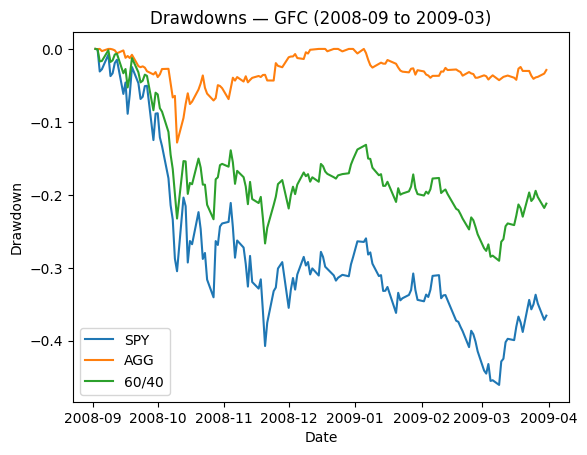

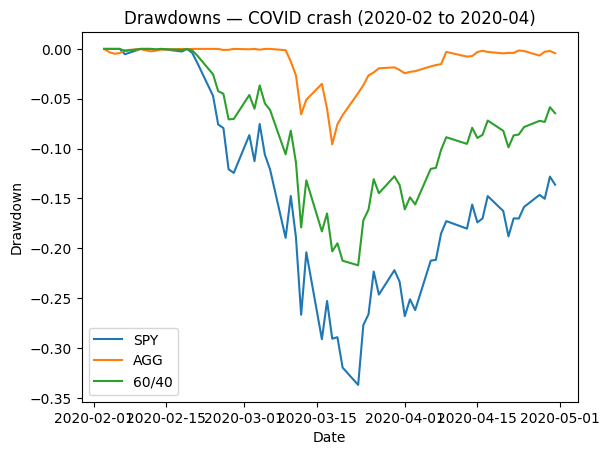

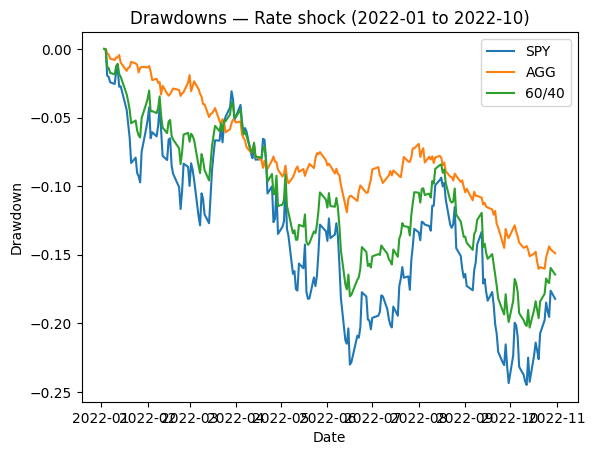

In [6]:
for name, (a, b) in stress_windows.items():
    sub = df.loc[a:b, assets].dropna()

    dd = pd.DataFrame({
        "SPY": drawdown_series(sub["SPY_RET"]),
        "AGG": drawdown_series(sub["AGG_RET"]),
        "60/40": drawdown_series(sub["P_60_40"]),
    })

    plt.figure()
    plt.plot(dd.index, dd["SPY"], label="SPY")
    plt.plot(dd.index, dd["AGG"], label="AGG")
    plt.plot(dd.index, dd["60/40"], label="60/40")
    plt.title(f"Drawdowns — {name}")
    plt.xlabel("Date")
    plt.ylabel("Drawdown")
    plt.legend()
    plt.show()

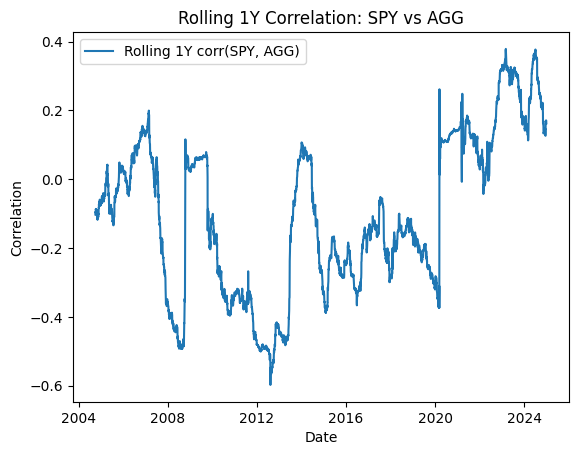

In [7]:
window = 252
roll_corr = df["SPY_RET"].rolling(window).corr(df["AGG_RET"])

plt.figure()
plt.plot(roll_corr.index, roll_corr, label="Rolling 1Y corr(SPY, AGG)")
plt.title("Rolling 1Y Correlation: SPY vs AGG")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.legend()
plt.show()

In [8]:
sector_map = {
    "Tech": ["Softw", "Chips"],
    "Financials": ["Banks", "Insur", "Fin"],
    "Energy": ["Oil", "Coal", "Mines"],
    "Industrials": ["Mach", "Trans", "Aero"],
    "Consumer": ["Food", "Rtail", "Meals"],
    "Healthcare": ["Hlth", "MedEq", "Drugs"],
}

sectors = pd.DataFrame({k: df[cols].mean(axis=1) for k, cols in sector_map.items()}, index=df.index)
sectors.head()

,Tech,Financials,Energy,Industrials,Consumer,Healthcare
date,,,,,,
2003-09-22,-0.00980,-0.007333,-0.002333,-0.007967,-0.005000,-0.001200
2003-09-23,0.01575,0.006067,0.004033,0.005267,0.007000,0.011000
2003-09-24,-0.02380,-0.009733,0.005067,-0.017167,-0.005833,-0.015200
2003-09-25,-0.02480,-0.011900,-0.018233,-0.014300,-0.011667,-0.020033
2003-09-26,-0.02665,-0.009300,-0.020533,-0.012967,-0.013000,-0.021533


In [9]:
factor_cols = ["mktrf", "smb", "hml", "umd"]
driver_cols = factor_cols + list(sectors.columns)

def fit_model(sub: pd.DataFrame):
    Y = sub["P_60_40"]
    X = sm.add_constant(sub[driver_cols])
    model = sm.OLS(Y, X).fit()
    return model

def approx_driver_contrib(sub: pd.DataFrame, model) -> pd.DataFrame:
    Y = sub["P_60_40"]
    betas = model.params.drop("const", errors="ignore")

    contrib = {}
    for col in betas.index:
        contrib[col] = float((betas[col] * sub[col]).var(ddof=0))

    total = float(Y.var(ddof=0))
    out = pd.Series(contrib).sort_values(ascending=False)
    return pd.DataFrame({
        "Var contrib": out,
        "% total var": out / total
    })

In [10]:
regimes = {
    "Pre-GFC (2003-09 to 2007-12)": ("2003-09-20", "2007-12-31"),
    "GFC (2008-01 to 2009-12)": ("2008-01-01", "2009-12-31"),
    "QE/Low-vol (2010-01 to 2019-12)": ("2010-01-01", "2019-12-31"),
    "COVID era (2020-01 to 2021-12)": ("2020-01-01", "2021-12-31"),
    "Inflation/Rate shock (2022-01 to 2024-12)": ("2022-01-01", "2024-12-31"),
}

In [ ]:
results = {}
tables = []

for name, (a, b) in regimes.items():
    sub = pd.concat([df[["P_60_40"] + factor_cols], sectors], axis=1).loc[a:b].dropna()

    if len(sub) < 252:
        print("Skipping (too few obs):", name, len(sub))
        continue

    m = fit_model(sub)
    c = approx_driver_contrib(sub, m)

    results[name] = {"model": m, "contrib": c, "n": len(sub), "r2": m.rsquared}

    top = c.head(10).copy()
    top.insert(0, "Regime", name)
    tables.append(top.reset_index().rename(columns={"index": "Driver"}))

regime_top = pd.concat(tables, ignore_index=True)
regime_top.head()

,Driver,Regime,Var contrib,% total var
0,mktrf,Pre-GFC (2003-09 to 2007-12),2.087983e-05,1.028361
1,smb,Pre-GFC (2003-09 to 2007-12),1.715012e-07,0.008447
2,Tech,Pre-GFC (2003-09 to 2007-12),3.842730e-08,0.001893
3,Industrials,Pre-GFC (2003-09 to 2007-12),3.478413e-08,0.001713
4,Consumer,Pre-GFC (2003-09 to 2007-12),2.435654e-08,0.001200


In [12]:
rows = []
for name, d in results.items():
    m = d["model"]
    rows.append({
        "Regime": name,
        "Obs": d["n"],
        "R2": d["r2"],
        "Residual share (1-R2 approx)": 1.0 - d["r2"],
    })

pd.DataFrame(rows).set_index("Regime")

,Obs,R2,Residual share (1-R2 approx)
Regime,,,
Pre-GFC (2003-09 to 2007-12),1072,0.900210,0.099790
GFC (2008-01 to 2009-12),505,0.941478,0.058522
QE/Low-vol (2010-01 to 2019-12),2516,0.974568,0.025432
COVID era (2020-01 to 2021-12),505,0.969941,0.030059
Inflation/Rate shock (2022-01 to 2024-12),753,0.940807,0.059193


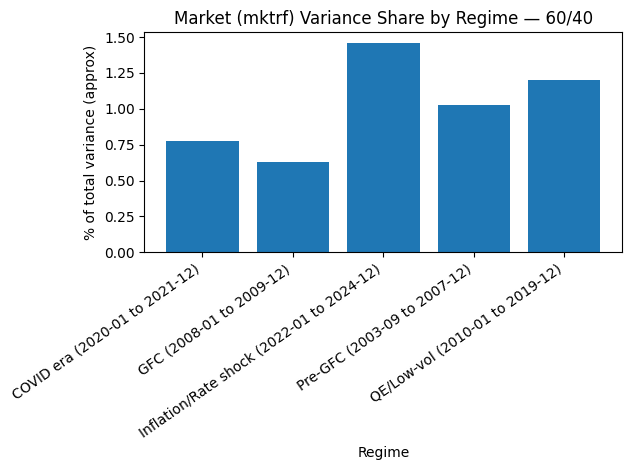

In [13]:
mkt_share = []
for name, d in results.items():
    c = d["contrib"]
    share = float(c.loc["mktrf", "% total var"]) if "mktrf" in c.index else np.nan
    mkt_share.append((name, share))

mkt_share = pd.Series(dict(mkt_share)).sort_index()

plt.figure()
plt.bar(mkt_share.index, mkt_share.values)
plt.title("Market (mktrf) Variance Share by Regime — 60/40")
plt.xlabel("Regime")
plt.ylabel("% of total variance (approx)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [14]:
drivers_to_show = ["mktrf", "smb", "hml", "umd", "Tech", "Financials", "Energy", "Industrials", "Consumer", "Healthcare"]

wide = pd.DataFrame(index=results.keys(), columns=drivers_to_show, dtype=float)

for name, d in results.items():
    c = d["contrib"]
    for drv in drivers_to_show:
        if drv in c.index:
            wide.loc[name, drv] = float(c.loc[drv, "% total var"])

wide = wide.fillna(0.0)

wide

,mktrf,smb,hml,umd,Tech,Financials,Energy,Industrials,Consumer,Healthcare
Pre-GFC (2003-09 to 2007-12),1.028361,0.008447,0.000013,0.000062,0.001893,0.001055,0.000621,0.001713,0.001200,0.001081
GFC (2008-01 to 2009-12),0.627708,0.025167,0.006318,0.000613,0.001513,0.000662,0.000416,0.001997,0.001927,0.011351
QE/Low-vol (2010-01 to 2019-12),1.203649,0.002567,0.000835,0.000034,0.002746,0.001813,0.000162,0.000294,0.000060,0.000116
COVID era (2020-01 to 2021-12),0.775546,0.007458,0.003736,0.000023,0.004234,0.000517,0.000015,0.009074,0.009217,0.000001
Inflation/Rate shock (2022-01 to 2024-12),1.459919,0.003747,0.003040,0.001673,0.022332,0.019698,0.002728,0.000147,0.000002,0.000063


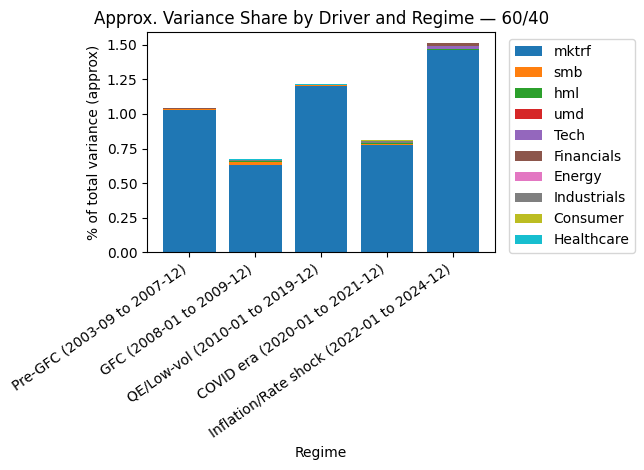

In [15]:
plt.figure()
bottom = np.zeros(len(wide))
x = np.arange(len(wide.index))

for col in wide.columns:
    plt.bar(x, wide[col].values, bottom=bottom, label=col)
    bottom += wide[col].values

plt.title("Approx. Variance Share by Driver and Regime — 60/40")
plt.xlabel("Regime")
plt.ylabel("% of total variance (approx)")
plt.xticks(x, wide.index, rotation=35, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 04 — Stress & Regime Analysis

This notebook examines how the risk profile and risk drivers of a 60/40 portfolio
change across market stress episodes and macroeconomic regimes.

The objective is to demonstrate that diversification and factor structure are
**regime-dependent**, rather than stable over time.

## Stress Windows: Performance and Risk

The following stress periods are analysed:

- **Global Financial Crisis (2008–09)**
- **COVID-19 crash (2020)**
- **Inflation / Rate shock (2022)**

These windows capture fundamentally different sources of stress:
financial-system collapse, sudden demand shock, and monetary tightening.

## Stress Window Summary Statistics

| Window | SPY Cum | AGG Cum | 60/40 Cum | SPY Max DD | AGG Max DD | 60/40 Max DD | SPY Ann Vol | AGG Ann Vol | 60/40 Ann Vol |
|------|--------|--------|----------|-----------|------------|--------------|-------------|--------------|----------------|
| GFC (2008–09) | −36.95% | +3.43% | −21.39% | −46.05% | −12.83% | −29.04% | 56.2% | 15.5% | 34.9% |
| COVID (2020) | −9.16% | +2.79% | −3.57% | −33.70% | −9.58% | −21.70% | 59.1% | 16.2% | 37.1% |
| Rate Shock (2022) | −17.75% | −15.48% | −16.38% | −24.50% | −16.03% | −20.32% | 24.4% | 7.8% | 15.7% |

## Interpretation: Stress Window Results

### Equity-led crises (GFC, COVID)
- Bonds provide **positive returns** or limited drawdowns.
- The 60/40 portfolio significantly reduces losses relative to SPY.
- Diversification works as intended.

### Rate-driven shock (2022)
- Both equities and bonds experience large drawdowns.
- Bond volatility increases materially.
- The 60/40 portfolio loses its traditional defensive advantage.

**Key insight:**  
Diversification effectiveness depends critically on the macroeconomic source of stress.

## Drawdown Dynamics

The drawdown plots reinforce three distinct regimes:

- **GFC:** prolonged and deep equity drawdowns, with bonds acting as a stabiliser.
- **COVID:** sharp but short-lived equity collapse, rapidly reversed by policy support.
- **2022:** persistent drawdowns across all assets, driven by inflation and rate repricing.

This highlights that tail risk is not only about magnitude, but also **duration and correlation structure**.

## Rolling Correlation: SPY vs AGG

The rolling 1-year correlation between SPY and AGG exhibits strong time variation:

- Predominantly **negative or low** during equity crises (2008–09, 2020).
- Turns **positive** during the inflationary regime post-2020.

### Implication
The stock–bond correlation is not structurally negative.
When inflation dominates, bonds cease to hedge equity risk.

## Regime-Based Risk Decomposition

The sample is divided into five macro regimes:

1. Pre-GFC (2003–2007)
2. GFC (2008–2009)
3. QE / Low-volatility (2010–2019)
4. COVID era (2020–2021)
5. Inflation / Rate shock (2022–2024)

Within each regime, factor and sector variance contributions are estimated.

## Model Fit by Regime

| Regime | Obs | R² | Residual Share |
|------|----|-----|----------------|
| Pre-GFC | 1072 | 0.900 | 0.100 |
| GFC | 505 | 0.941 | 0.059 |
| QE / Low-vol | 2516 | 0.975 | 0.025 |
| COVID era | 505 | 0.970 | 0.030 |
| Inflation / Rate shock | 753 | 0.941 | 0.059 |

### Interpretation
- Systematic factors explain most variance in all regimes.
- Residual (unexplained) risk rises during crisis periods.
- Risk becomes less compressible during structural shocks.

## Market Factor Dominance Across Regimes

The market factor (mktrf) dominates variance contributions in every regime:

- Lowest during the GFC (~63%)
- Highest during the inflation/rate shock (>145%)

### Key Insight
> When diversification fails, **market risk concentration increases**, not decreases.

The 2022 regime represents an extreme case of market-driven repricing across asset classes.

## Sector Contributions by Regime

Sector contributions remain small relative to the market factor but vary meaningfully:

- **GFC:** Consumer and Healthcare increase in importance.
- **QE era:** Risk is highly compressed and market-dominated.
- **COVID era:** Industrials and Consumer sectors gain prominence.
- **Inflation regime:** Tech and Financials contributions rise sharply.

### Interpretation
Sector effects enhance **economic interpretation**, even when their variance contribution is small.

## Summary and Implications

- The 60/40 portfolio exhibits strong long-run diversification benefits.
- Diversification is effective in equity-led crises but fragile during inflationary shocks.
- Market risk dominates across all regimes, especially when correlations rise.
- Factor and sector decomposition provides insight into *why* diversification fails, not just *when*.

Overall, portfolio risk is best understood as **state-dependent**, rather than static.

## Final Takeaway

Risk is not eliminated by diversification — it is **transformed**.

Understanding how risk sources change across regimes is essential for
portfolio construction, stress testing, and risk management.